In [6]:
pip install pandas numpy scikit-learn imbalanced-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('creditcard.csv')

# Data Cleaning and Exploration

In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.shape
print("\nMissing Values:")
print(df.isnull().sum().max())
df.describe()


Missing Values:
0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Transaction Counts:
284807

Percentage of Fraudulent Transactions: 0.173%


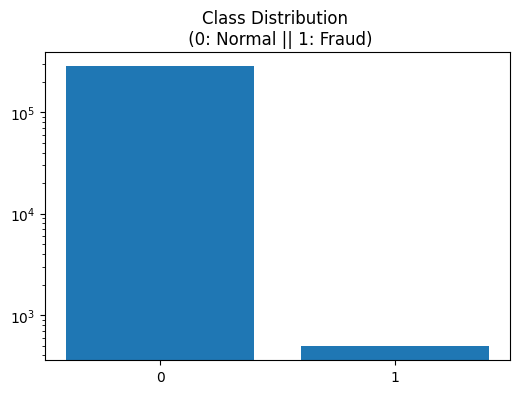

In [10]:
print("Transaction Counts:")
print(len(df))

fraud_percentage = (len(df[df['Class'].astype(int)==1])/ len(df)) * 100
print(f"\nPercentage of Fraudulent Transactions: {fraud_percentage:.3f}%")

class_counts = df[['Class','Amount']].groupby('Class').count().reset_index()
class_counts['Class'] = class_counts['Class'].astype(str)
class_counts
plt.figure(figsize=(6, 4))
plt.bar(class_counts['Class'], class_counts['Amount'])
plt.title('Class Distribution \n (0: Normal || 1: Fraud)')
plt.yscale('log') 
plt.show()

Given the high amount of non-fraudulent transactions, training a model on this may lead to the model just guessing 'not fraud'. As such we need to hone in on the fraud cases while training a model.

# Data Preprocessing & Splitting

In [11]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

# .values
# When you pull a single column out of your dataset using df['Amount'], Pandas doesn't just give you a list of numbers. It gives you a Pandas "Series," which includes the row numbers (the index), the data type, and the name of the column.
# When you add .values to the end of it (df['Amount'].values), it deletes the index and the name, converting the data into a raw NumPy array (a basic, flat list of numbers)

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time','Amount'], axis=1, inplace=True)

# Look at the new columns to confirm
df[['scaled_amount', 'scaled_time']].head()

,scaled_amount,scaled_time
0,1.783274,-0.994983
1,-0.269825,-0.994983
2,4.983721,-0.994972
3,1.418291,-0.994972
4,0.670579,-0.994960


In [12]:
from sklearn.model_selection import train_test_split

# Separate our features (X) from our target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Perform the split
# 'stratify=y' is crucial here! It ensures our tiny 0.17% of fraud 
# is evenly distributed between the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape (Features): {X_train.shape}")
print(f"Testing data shape (Features): {X_test.shape}")

Training data shape (Features): (227845, 30)
Testing data shape (Features): (56962, 30)


# Class Imbalance

The key thing here is to tackle what we mentioned where the model will just always get 'non-fraudulent' to achieve the highest accuracy. Here are some ways to do this:
* Undersampling: Randomly deleting hundreds of thousands of "Normal" transactions until we only have 492 left to match our fraud count. (We lose a lot of good data this way).
* Oversampling: Creating synthetic (fake but mathematically realistic) "Fraud" transactions until they equal the number of "Normal" transactions. <br>

The technique employed here is an industry-standard oversampling technique - SMOTE (Synthetic Minority Over-sampling Technique).
* it looks at a fraudulent transaction, finds its nearest fraudulent neighbors in the dataset, and draws a line between them. It then drops a brand new, synthetic data point somewhere along that line - ultimately mapping a neighbourhood of what fraud looks like
* ALWAYS only apply SMOTE to training data, since you only want to test on real data

In [13]:
from imblearn.over_sampling import SMOTE

# random_state controls the randomness in your code so that your results are perfectly reproducible.
smote = SMOTE(random_state=42)

# Fit SMOTE to the training data ONLY
# This creates new synthetic X features and matching y labels
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# print methods
# .format() Method -> curly braces {} act as an empty box or a placeholder, whatever we put inside the parentheses of .format() gets dynamically injected into that empty box.
# f-Strings (print(f"Dataset Shape: {df.shape}")) -> lowercase f right before the opening quotation mark. This tells Python, "Hey, this isn't a normal string; be ready to evaluate variables inside it, Instead of leaving the curly braces {} empty and filling them later, you put the variable name directly inside the braces.
# f-string numbers -> print(f"Percentage of Fraud: {fraud_percentage:.3f}%")
  # : = "I am about to give you formatting instructions."
  # .3 = "Round the number to exactly 3 decimal places."
  # f = "Treat this as a float (a decimal number)."

# sum(y_train == 1) works in two steps: returns a true or false series, and true = 1 so summing gives you the amount
print("Before SMOTE, counts of label '1' (Fraud): {}".format(sum(y_train == 1)))
print("Before SMOTE, counts of label '0' (Normal): {} \n".format(sum(y_train == 0)))

print("After SMOTE, the shape of train_X: {}".format(X_train_smote.shape))
print("After SMOTE, the shape of train_y: {} \n".format(y_train_smote.shape))

print("After SMOTE, counts of label '1' (Fraud): {}".format(sum(y_train_smote == 1)))
print("After SMOTE, counts of label '0' (Normal): {}".format(sum(y_train_smote == 0)))

/Users/pierson.chu/Downloads/github/fraud_detection_model/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Before SMOTE, counts of label '1' (Fraud): 394
Before SMOTE, counts of label '0' (Normal): 227451 

After SMOTE, the shape of train_X: (454902, 30)
After SMOTE, the shape of train_y: (454902,) 

After SMOTE, counts of label '1' (Fraud): 227451
After SMOTE, counts of label '0' (Normal): 227451


# Model Training

## Model Types
* Unsupervised Learning: You give the computer a massive pile of data with no answers or labels, and ask it to find hidden groupings (e.g., segmenting customers based on purchasing behavior)
* Reinforcement Learning: You put the computer in an environment with a point system. It learns by trial and error, getting "punished" for mistakes and "rewarded" for success (e.g., training an AI to play Mario or drive a car).
* Supervised Learning: You give the computer the data and the exact answers (labels), letting it study the relationship between the two. 

### Logistic Regression
Logistic Regression is a supervised learning, classification algorithm. Think of it as a model that tries to draw a single, straight mathematical line (a decision boundary) through your data to separate the "Normal" from the "Fraud."
* It looks at a transaction's features (Time, Amount, V1, V2, etc.) and calculates a probability score between 0 and 1.
* If the score is above 0.50, it classifies it as Fraud (1). If it's below 0.50, it classifies it as Normal (0).
* Because we used SMOTE to artificially flood the training zone with fraud cases, the Logistic Regression model drew a very aggressive line. 
* It essentially learned, "When in doubt, guess Fraud!" That's why your Recall was incredibly high (92%), but your Precision was abysmal (6%)—it caught the fraud, but it also caught everything else near that straight line.

### Random Forest
Random Forest is a supervised learning, and is an "ensemble" model, meaning it is actually made up of hundreds of smaller models working together. Those smaller models are called Decision Trees.
* The Decision Tree: Imagine a giant flowchart. A single tree looks at a transaction and asks a series of yes/no questions. (e.g., "Is the Amount greater than $500?" -> If yes, "Did it happen between 2 AM and 4 AM?" -> If yes, "Is feature V4 greater than 2.5?").
* The Forest: A single tree is prone to making mistakes. So, a Random Forest builds hundreds of these trees (in your code, n_estimators=100 meant 100 trees). It gives each tree a slightly different, random slice of the training data so they all learn slightly different rules.
* The Vote: When a new, unseen transaction comes in, all 100 trees look at it and cast a vote. If 85 trees vote "Normal" and 15 vote "Fraud", the forest outputs "Normal" because the majority wins.

<br> <img src="licensed-image (2).jpeg" width = "350" height = "200"/>

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the models
# We use random_state again so our results are perfectly reproducible!
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train (Fit) the models on the BALANCED training data
print("Training Logistic Regression...")
log_reg.fit(X_train_smote, y_train_smote)

print("Training Random Forest... (This might take a minute or two!)")
rf_clf.fit(X_train_smote, y_train_smote)

print("\nModels trained successfully!")

# 3. Make predictions on the UNTOUCHED, unbalanced test data
y_pred_log_reg = log_reg.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

print("Predictions generated!")

Training Logistic Regression...
Training Random Forest... (This might take a minute or two!)

Models trained successfully!
Predictions generated!


# Evaluation

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


--- Random Forest Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



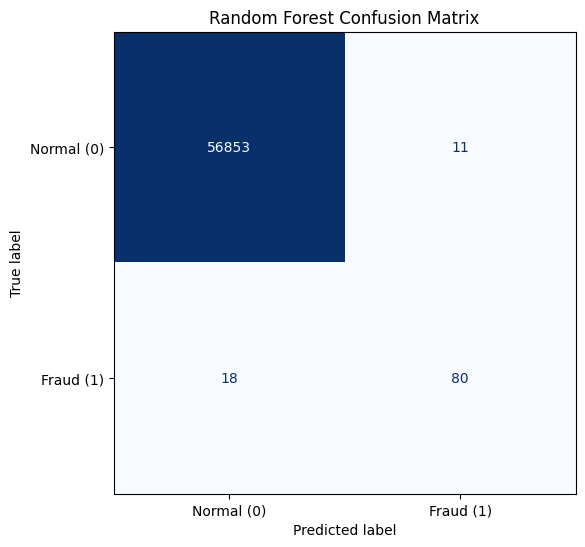

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Evaluate Logistic Regression
print("--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_log_reg))

# 2. Evaluate Random Forest
print("\n--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

# 3. Visualize the Random Forest Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Fraud (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest Confusion Matrix')
plt.show()

# Explaining the results
For reference 0 is normal, and 1 is fraud

## Logistic Regression
* Support: column tells us there were exactly 98 actual fraud cases hidden among 56,864 normal transactions in your test exam.
* Recall: 0.92 (92%). It caught roughly 90 out of the 98 frauds! It cast a massive net.
* Precision: 0.06 (6%). This is terrible. It means 94% of the time this model yelled "FRAUD!", it was a false alarm. It caught a lot of fraud (high recall) simply by flagging almost everything that looked even slightly suspicious. Your bank's customer service line would be ringing off the hook with angry customers whose cards were wrongly declined.
* F1- Score: 0.11 (11%). Very poor balance. A combined mathematical score that balances Precision and Recall. You use this when you want a model that is "good enough" at both, rather than extreme in just one.

$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

F1-Score uses a different type of math called the Harmonic Mean rather than a simple average. The harmonic mean is incredibly strict: it heavily punishes models if either Precision or Recall is low. In order to get a high F1-Score, both metrics must be high.

## Random Forest
* Support: column tells us there were exactly 98 actual fraud cases hidden among 56,864 normal transactions in your test exam.
* Recall: 0.82 (82%). It caught roughly 80 out of the 98 frauds. Its net was a bit smaller.
* Precision: 0.88 (88%). This is excellent. When Random Forest flags a transaction as fraud, it is right 88% of the time.
* F1- Score: 0.85 (Great balance).